## Setup — run this first

This workshop uses helper modules from its GitHub repository (dataset loading, the
spiking-network models, and plotting utilities). The cell below **installs the
repository as a package** — along with external dependencies such as `aeon` (used to
download the dataset) — so that `import snn_workshop` works on Google Colab. PyTorch,
NumPy and Matplotlib are already available on Colab.

> Running locally from a clone instead? Use `pip install -e .` in the repo root; the
> cell below detects that `snn_workshop` is already importable and skips the install.

In [1]:
# Install the workshop package (and its dependencies, e.g. aeon) if needed.
import importlib.util, subprocess, sys

REPO_URL = "https://github.com/rwvos/bisccits-snn-workshop.git"  # workshop repository

if importlib.util.find_spec("snn_workshop") is None:
    print(f"Installing snn_workshop (+ aeon and other dependencies) from {REPO_URL} ...")
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", f"git+{REPO_URL}"],
        check=True,
    )
    print("Installation complete.")
else:
    print("snn_workshop already importable — skipping install.")

snn_workshop already importable — skipping install.


# Chapter 1 — Defining a Spiking Neural Network

**BISCCITS workshop · Spiking Neural Networks**

Welcome! Over three chapters we will go from a single biological-style neuron to a
*trained, efficient* spiking neural network (SNN), and we will measure exactly where
that efficiency comes from.

- **Chapter 1 (this one) — Defining SNNs.** What equations govern a spiking neuron,
  and how do we write them down so a computer can simulate them?
- **Chapter 2 — Training SNNs.** How do we train a network of spiking neurons with
  the same machinery (backpropagation) used for ordinary deep nets, despite the spike
  being non-differentiable — and how do we make it *fast*?
- **Chapter 3 — Evaluating SNNs.** Once trained, what does the network actually do at
  inference, and how much cheaper is it than a conventional network?

This workshop assumes you are comfortable with the *biology* of neurons but **not**
with machine learning. We introduce every ML idea from scratch.

> **Objective of Chapter 1.** Implement a leaky integrate-and-fire (LIF) neuron from
> its equations, see its dynamics, and understand the one trick that will later let us
> train spiking networks: the *surrogate gradient*.

## From a biological neuron to a leaky integrate-and-fire model

A biological neuron integrates incoming current on its membrane. The membrane leaks
charge over time, so it behaves like a **low-pass filter**: steady input charges it
up, and when the input stops it relaxes back toward rest. When the membrane potential
crosses a **threshold**, the neuron emits a **spike** and its potential is **reset**.

The simplest model capturing this is the **leaky integrate-and-fire (LIF)** neuron.
In continuous time:

$$\tau_\text{mem}\,\frac{dV(t)}{dt} = -V(t) + I(t), \qquad \text{spike when } V \ge V_\text{thr},\ \text{then } V \leftarrow V_\text{reset}.$$

For simulation (and for PyTorch later) we use the **discrete-time** version. With a
step `dt` and decay `beta = exp(-dt / tau_mem)`:

$$
\begin{aligned}
V[t] &= \beta\, V[t-1] + (1-\beta)\, I[t] && \text{(leaky integration / low-pass filter)}\\
S[t] &= \begin{cases}1 & V[t] \ge V_\text{thr}\\ 0 & \text{otherwise}\end{cases} && \text{(threshold $\rightarrow$ spike)}\\
V[t] &\leftarrow V_\text{reset} \quad \text{if } S[t]=1 && \text{(hard reset)}
\end{aligned}
$$

`beta` controls memory: `beta -> 1` means a long membrane time constant (slow,
strongly smoothing), `beta -> 0` means the neuron almost instantly follows its input.

**Setup.** Import NumPy, PyTorch and Matplotlib, plus the workshop helpers, and fix a
random seed for reproducibility.

In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from snn_workshop import set_seed
from snn_workshop.viz import plot_membrane_dynamics

set_seed(0)

## Subtask 1 — Simulate one LIF neuron

We will integrate the three equations above over time, given an input current `I(t)`.
Note the order *inside* each timestep: **integrate → check threshold → reset**. The
reset applies to the state carried into the *next* step, which produces the
characteristic "sawtooth" membrane trace.

**TASK.** Implement `lif_simulate(current, beta, threshold, v_reset)` returning the
membrane trace `mem` and the binary `spikes` array. Use a plain Python loop over
timesteps — clarity first; we move to tensors in Chapter 2.

In [3]:
def lif_simulate(current, beta, threshold=1.0, v_reset=0.0):
    """Simulate one leaky integrate-and-fire neuron over time.

    Discrete-time LIF as a *low-pass filter* of the input current with a *hard reset*:

        V[t] = beta * V[t-1] + (1 - beta) * I[t]     # leaky integration
        S[t] = 1  if V[t] >= threshold  else 0       # threshold -> spike
        V[t] <- v_reset  if S[t] == 1                # hard reset

    `beta = exp(-dt/tau_mem)` is the membrane decay (0 < beta < 1): larger beta =
    longer memory = stronger low-pass smoothing.

    Parameters
    ----------
    current : array (T,)   input current I(t)
    beta    : float        membrane decay in (0, 1)
    threshold, v_reset : float

    Returns
    -------
    mem   : array (T,)   membrane potential recorded *at* each step (peaks at spikes)
    spikes: array (T,)   binary spike train
    """
    current = np.asarray(current, dtype=np.float64)
    T = len(current)
    mem = np.zeros(T)
    spikes = np.zeros(T)

    v = v_reset  # state carried between steps
    for t in range(T):
        v = beta * v + (1.0 - beta) * current[t]   # leaky integration
        s = 1.0 if v >= threshold else 0.0          # spike?
        mem[t] = v                                  # record the value that crossed
        spikes[t] = s
        if s > 0.5:
            v = v_reset                             # hard reset for the next step
    return mem, spikes

## Visualising the dynamics

We drive the neuron with a current that is off, then a constant pulse, then off
again, and plot three panels: the input current, the membrane potential (with the
threshold), and the output spikes. You should see the membrane charge up like a
low-pass filter, fire periodically while driven, reset after each spike, and decay
once the input stops.

*(No task — run this cell to produce the dynamics plot.)*

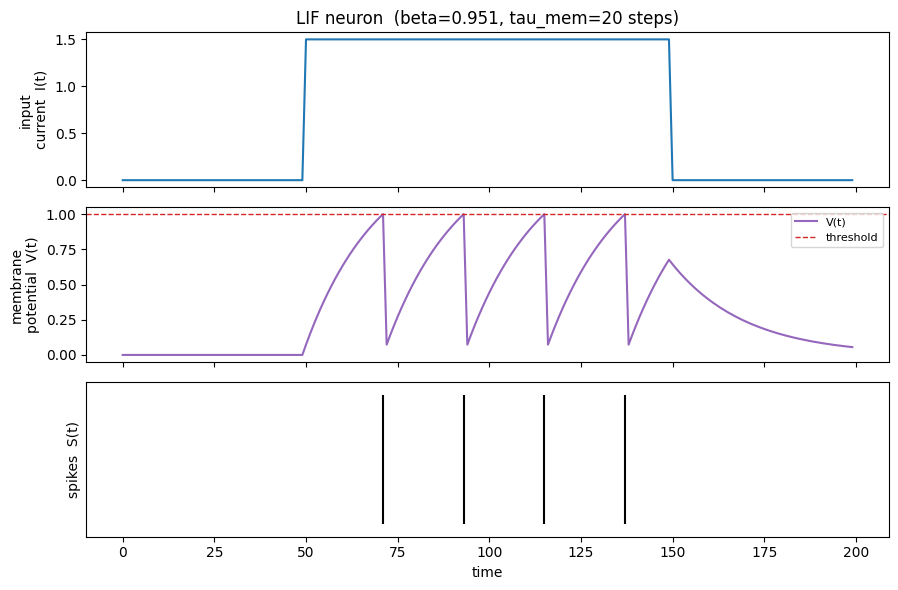

spike count: 4


In [4]:
T = 200
dt = 1.0

# A current that is off, then a constant drive, then off again.
current = np.zeros(T)
current[50:150] = 1.5

beta = np.exp(-dt / 20.0)  # tau_mem = 20 steps
mem, spikes = lif_simulate(current, beta=beta, threshold=1.0)

fig, _ = plot_membrane_dynamics(
    current, mem, spikes, threshold=1.0, dt=dt,
    title=f"LIF neuron  (beta={beta:.3f}, tau_mem=20 steps)",
)
plt.show()
print(f"spike count: {int(spikes.sum())}")

The slope of the charge-up and the firing frequency are both set by the membrane time
constant `tau_mem` (equivalently `beta`). A longer `tau_mem` integrates input over a
longer window — more smoothing, slower firing.

**TASK.** Drive the neuron with the *same* step current for several `tau_mem` values
(e.g. 5, 20, 60 steps) and compare the membrane traces and firing rates. Confirm that
a larger `tau_mem` charges more slowly and fires less often.

tau=   5  rate=0.100 spikes/step
tau=  20  rate=0.025 spikes/step
tau=  60  rate=0.005 spikes/step


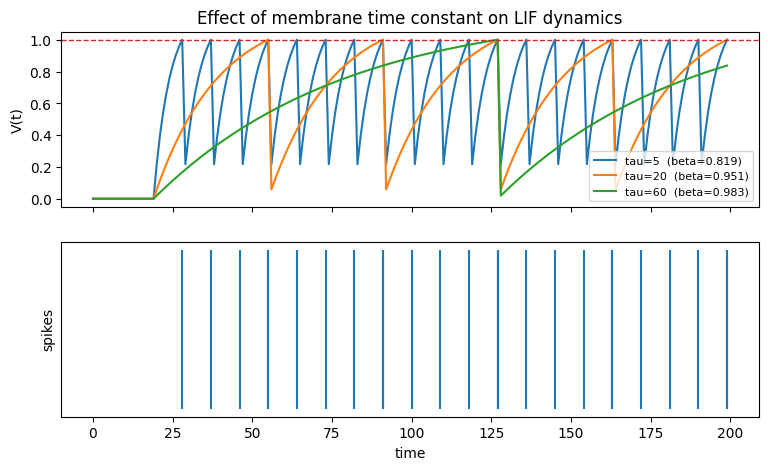

In [5]:
# Drive the neuron with the same step current for several values of tau_mem and
# compare both the membrane trace and the resulting firing rate.
taus = [5.0, 20.0, 60.0]
step = np.zeros(T)
step[20:] = 1.2

fig, axes = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
for tau in taus:
    b = np.exp(-dt / tau)
    m, s = lif_simulate(step, beta=b, threshold=1.0)
    axes[0].plot(np.arange(T) * dt, m, label=f"tau={tau:.0f}  (beta={b:.3f})")
    axes[1].vlines(np.arange(T)[s > 0.5] * dt, 0, 1, label=f"tau={tau:.0f}")
    print(f"tau={tau:>4.0f}  rate={s.mean():.3f} spikes/step")
axes[0].axhline(1.0, color="tab:red", ls="--", lw=1)
axes[0].set_ylabel("V(t)")
axes[0].legend(fontsize=8)
axes[0].set_title("Effect of membrane time constant on LIF dynamics")
axes[1].set_yticks([])
axes[1].set_ylabel("spikes")
axes[1].set_xlabel("time")
plt.show()

## The problem we will face in Chapter 2 — and the surrogate gradient

To *train* a network we need gradients: how does the loss change if we nudge a weight?
Gradients flow backward through every operation — but the spike is a **Heaviside step
function** of the membrane potential, and its derivative is **zero everywhere** (and
undefined exactly at the threshold). No gradient can flow through a spike.

The fix used throughout modern SNN training is the **surrogate gradient**: keep the
hard spike in the *forward* pass, but in the *backward* pass pretend the spike was a
smooth function. A common choice is the **derivative of a sigmoid**,
$\frac{d}{dV}\,\sigma\!\big(k\,(V - V_\text{thr})\big)$, a bump centred on the
threshold. The **slope** `k` controls its width: small `k` spreads gradient over a
wide range of membrane potentials (smooth but biased), large `k` concentrates it near
the threshold (sharp, closer to the true step but with vanishing gradient away from
threshold).

**TASK.** Plot the Heaviside spike together with the sigmoid-derivative surrogate
gradient for a few slope values `k` (e.g. 1, 5, 25). Observe how the slope trades
gradient *width* against *sharpness*. We will plug exactly this surrogate into the
backward pass in Chapter 2.

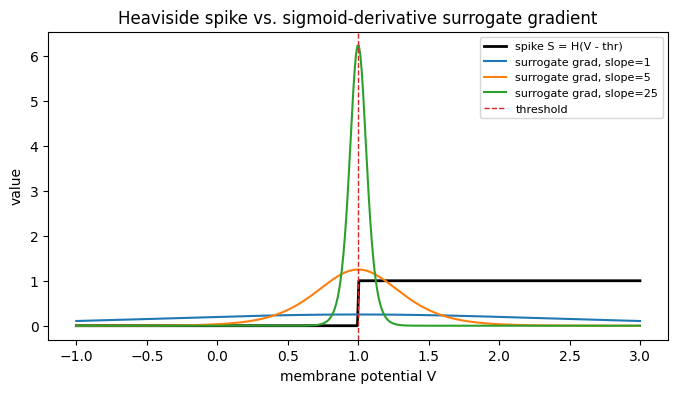

In [6]:
# The spike is a Heaviside step: its derivative is 0 everywhere (and undefined at 0),
# so gradients cannot flow. During the *backward* pass we replace it with a smooth
# surrogate: the derivative of a sigmoid sigma(beta_s * v), peaked at threshold.
def heaviside(v, threshold=1.0):
    return (v >= threshold).astype(np.float64)


def sigmoid_surrogate_grad(v, threshold=1.0, slope=5.0):
    """d/dv of sigma(slope * (v - threshold)) -- a bump centred at the threshold."""
    x = slope * (v - threshold)
    sig = 1.0 / (1.0 + np.exp(-x))
    return slope * sig * (1.0 - sig)


v = np.linspace(-1.0, 3.0, 400)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(v, heaviside(v), color="black", lw=2, label="spike S = H(V - thr)")
for slope in [1.0, 5.0, 25.0]:
    ax.plot(v, sigmoid_surrogate_grad(v, slope=slope), label=f"surrogate grad, slope={slope:g}")
ax.axvline(1.0, color="tab:red", ls="--", lw=1, label="threshold")
ax.set_xlabel("membrane potential V")
ax.set_ylabel("value")
ax.set_title("Heaviside spike vs. sigmoid-derivative surrogate gradient")
ax.legend(fontsize=8)
plt.show()

### Recap

You implemented a LIF neuron, saw that it is a leaky low-pass integrator that fires
and resets, and met the surrogate gradient that makes spiking networks trainable.
**Next:** stack these neurons into layers, build a deep SNN, and train it on real
sensor data.

# Chapter 2 — Training a Spiking Neural Network

In Chapter 1 we built a single LIF neuron and met the surrogate gradient. Now we will:

1. stack LIF neurons into a **deep spiking network**,
2. train it on a real movement-sensor dataset with **backpropagation through time** using
   the surrogate gradient, and
3. make training **fast** with *forward-gradient injection* + `torch.compile`,
   benchmarking against a conventional MLP and a GRU.

> **Objective.** Train a 3-layer SNN end-to-end, and understand *why* the spike's
> non-differentiability is not an obstacle — and how to keep training efficient.

## From one neuron to a deep network

A **layer** of LIF neurons is just many neurons in parallel. Each neuron receives a
weighted sum of the layer's inputs as its input current:

$$I^{(\ell)}[t] = W^{(\ell)} \, s^{(\ell-1)}[t], \qquad
  V^{(\ell)}[t] = \beta\,V^{(\ell)}[t-1] + I^{(\ell)}[t],$$

then thresholds and resets exactly as before, emitting a spike vector
$s^{(\ell)}[t]$. We stack three such layers. The network is **feedforward in space**
(layer $\ell$ feeds layer $\ell+1$) but **recurrent in time**: each neuron's membrane
carries state from one timestep to the next. *This temporal recurrence is the
"recurrent dynamics" of the SNN* — there are no explicit lateral weights here.

Our input is a length-$T$ multivariate time series. At every timestep we feed one
sample $x[t]$ into the first layer. After the last spiking layer we apply a linear
**readout** at each timestep and **average the logits over time**; the time-averaged
logits go into a standard **cross-entropy** classification loss.

> Why average over time? Each timestep produces a noisy, spike-driven vote for each
> class. Averaging integrates evidence across the whole sequence into one prediction.

**Setup.** Imports and device selection (GPU if available — useful for the compile
demo later).

In [7]:
import os
import time
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from snn_workshop import set_seed, get_device
from snn_workshop.viz import (
    plot_training_curves, plot_metric_comparison, plot_method_grid,
    plot_runtime_bar, plot_confusion_matrices, plot_swing_3d,
)

set_seed(0)
DEVICE = get_device()
print("device:", DEVICE)

device: cpu


## Subtask 1 — The spike with a surrogate gradient

Recall the problem: the spike is a Heaviside step whose derivative is zero, so no
gradient flows. The classic fix in PyTorch is a **custom `autograd.Function`**: we
define the forward pass (the hard spike) and *override* the backward pass to use the
smooth surrogate from Chapter 1 (the derivative of a sigmoid).

This is the most explicit way to write it, and it makes the "different forward vs
backward" idea concrete. Its one drawback — which motivates Subtask 3 — is that a
custom `autograd.Function` cannot be traced by `torch.compile`.

**TASK.** Implement `SpikeFunction(torch.autograd.Function)`: `forward` returns
`(x >= 0).float()`; `backward` multiplies the incoming gradient by the
sigmoid-derivative surrogate `slope * σ(slope·x) · (1 − σ(slope·x))`. Wrap it in a
helper `spike_autograd(x, slope)`.

In [8]:
class SpikeFunction(torch.autograd.Function):
    """Heaviside in the forward pass; sigmoid-derivative surrogate in the backward."""

    @staticmethod
    def forward(ctx, x, slope):
        ctx.save_for_backward(x)
        ctx.slope = slope
        return (x >= 0).float()           # hard spike: 1 if membrane >= threshold

    @staticmethod
    def backward(ctx, grad_output):
        (x,) = ctx.saved_tensors
        sig = torch.sigmoid(ctx.slope * x)
        surrogate = ctx.slope * sig * (1.0 - sig)   # d/dx sigmoid(slope * x)
        return grad_output * surrogate, None         # None: no grad w.r.t. slope


def spike_autograd(x, slope=10.0):
    return SpikeFunction.apply(x, slope)

## Subtask 2 — The LIF layer and the deep SNN

Now we assemble the network. `LIFLayer` wraps a `nn.Linear` (the weights $W$) and
unrolls the LIF recurrence over time, calling our spike function each step and
applying the hard reset. `DeepSNN` stacks several `LIFLayer`s and adds the
time-averaged linear readout.

**TASK.** Implement `LIFLayer` (loop over time: integrate `v = beta*v + current`,
spike, hard-reset `v = v*(1-s)`, collect spikes) and `DeepSNN` (stack layers, then
`readout(spikes).mean(dim=1)`). Expose a `return_spikes`/`return_mem` flag — we reuse
it for the visualisations in Chapter 3.

In [9]:
class LIFLayer(nn.Module):
    """Linear -> leaky integrate-and-fire, unrolled over time (feedforward in space)."""

    def __init__(self, in_features, out_features, beta=0.9, threshold=1.0,
                 slope=10.0, spike_fn=spike_autograd):
        super().__init__()
        self.fc = nn.Linear(in_features, out_features)
        self.beta = beta
        self.threshold = threshold
        self.slope = slope
        self.spike_fn = spike_fn

    def forward(self, x, return_mem=False):
        B, T, _ = x.shape
        v = torch.zeros(B, self.fc.out_features, device=x.device, dtype=x.dtype)
        spikes, mems = [], []
        for t in range(T):
            current = self.fc(x[:, t, :])                       # input current I[t]
            v = self.beta * v + current                          # leaky integration
            s = self.spike_fn(v - self.threshold, self.slope)    # spike
            if return_mem:
                mems.append(v)
            v = v * (1.0 - s)                                    # hard reset to 0
            spikes.append(s)
        out = torch.stack(spikes, dim=1)                        # (B, T, out_features)
        if return_mem:
            return out, torch.stack(mems, dim=1)
        return out


class DeepSNN(nn.Module):
    """Stack of LIF layers + a linear readout averaged over time."""

    def __init__(self, n_in, hidden=64, n_layers=3, n_classes=4,
                 beta=0.9, threshold=1.0, slope=10.0, spike_fn=spike_autograd):
        super().__init__()
        sizes = [n_in] + [hidden] * n_layers
        self.layers = nn.ModuleList([
            LIFLayer(sizes[i], sizes[i + 1], beta=beta, threshold=threshold,
                     slope=slope, spike_fn=spike_fn)
            for i in range(n_layers)
        ])
        self.readout = nn.Linear(hidden, n_classes)

    def forward(self, x, return_spikes=False):
        s = x
        per_layer = []
        for layer in self.layers:
            s = layer(s)
            per_layer.append(s)
        logits = self.readout(s).mean(dim=1)    # readout per step, then mean over time
        if return_spikes:
            return logits, per_layer
        return logits

## The dataset — RacketSports

We use **RacketSports** from the UEA multivariate time-series archive. University
students played **badminton** or **squash** while wearing a **smartwatch**; the watch
streamed its accelerometer and gyroscope.

<img alt="University students playing racket sports while wearing a smartwatch — the source of the RacketSports dataset." width="480" style="max-width:100%;height:auto;" src="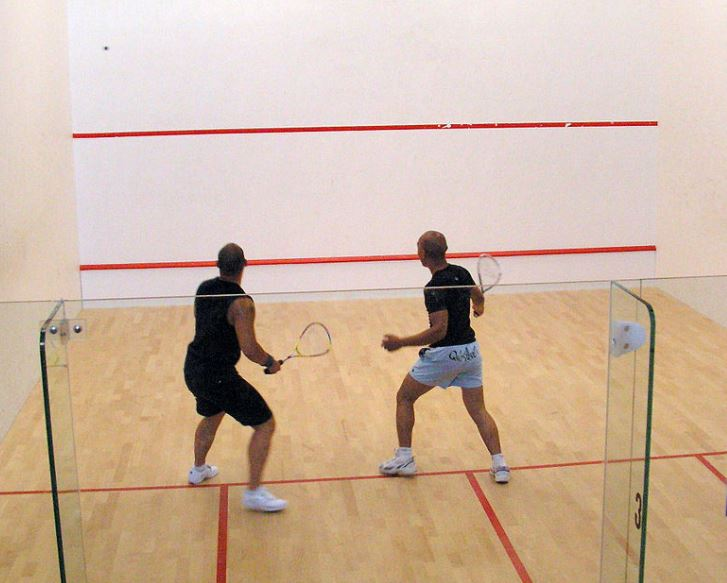">

*The RacketSports dataset was recorded from a smartwatch's accelerometer and gyroscope while players performed badminton and squash strokes ([Zenodo](https://zenodo.org/records/3742271)).*

| property | value |
|---|---|
| channels (C) | **6** — 3-axis accelerometer + 3-axis gyroscope |
| timesteps (T) | **30** — sampled at 10 Hz over ~3 seconds |
| classes | **4** — Badminton Clear, Badminton Smash, Squash Forehand Boast, Squash Backhand Boast |
| train / test | **151 / 152** trials |

Each trial is one stroke; the task is to identify the sport **and** the stroke. It is
small (fast to train) yet genuinely temporal — a good fit for spiking models. We
z-score each channel using training-set statistics, feed the 6 channels as the input
current at each of the 30 timesteps, and read out 4 class logits.

**Load the data** with the helper (`aeon` downloads it automatically) and move the
tensors to the device.

In [11]:
from snn_workshop.data import load_racket_sports

ds = load_racket_sports(normalize=True)
print(f"train {ds.X_train.shape}, test {ds.X_test.shape}")
print(f"T={ds.n_timesteps} timesteps, C={ds.n_channels} channels, "
      f"{ds.n_classes} classes: {ds.class_names}")

X_train = torch.tensor(ds.X_train, device=DEVICE)
y_train = torch.tensor(ds.y_train, device=DEVICE)
X_test = torch.tensor(ds.X_test, device=DEVICE)
y_test = torch.tensor(ds.y_test, device=DEVICE)

AttributeError: module 'coverage.types' has no attribute 'Tracer'

### What does one trial look like?

Before training, let us *see* a single swing. The 6 channels are hard to read as raw
traces, but three of them — the **accelerometer** axes — describe how the watch moves
through space. If we **integrate the acceleration twice** (acceleration → velocity →
position) we recover an approximate **3D trajectory of the swing**, and we can colour
that path by how hard the watch is accelerating at each instant.

> **Caveat.** Double-integrating a short, noisy accelerometer signal drifts, so this is
> an *illustrative* shape rather than a precise reconstruction. We remove gravity/bias
> (the per-axis mean) and a linear velocity drift to keep the path readable.

*(No task — reconstruct and plot one swing's 3D trajectory, coloured by acceleration
magnitude. Change `sample_idx` to explore other trials and classes.)*

In [ ]:
# Reconstruct the racket swing from its accelerometer signal: integrate acceleration
# twice (-> velocity -> position) to trace the watch's path through space, and colour
# the path by how hard the watch is accelerating at each moment.
# We use the *un-normalized* data here so the three accelerometer axes keep their true
# relative scale (the normalized `ds` rescales each channel independently).
ds_raw = load_racket_sports(normalize=False)

sample_idx = 0                                   # try other trials by changing this
accel = ds_raw.X_train[sample_idx, :, :3]        # channels 0-2 = 3-axis accelerometer
label = ds_raw.class_names[ds_raw.y_train[sample_idx]]

# RacketSports is sampled at 10 Hz, so each timestep is dt = 0.1 s.
plot_swing_3d(accel, dt=0.1, title=f"Swing trajectory — {label}")
plt.show()

## Training

`train_model` is a standard mini-batch Adam loop with cross-entropy loss. The only
thing that makes this "spiking" is the model — backpropagation through time and the
optimiser are exactly what you would use for any recurrent network, because the
surrogate gradient lets gradients flow through the spikes. We record **train
accuracy**, **test accuracy** (the dataset ships with its own split), and **wall-clock
training time**.

*(No task — train the SNN built from your custom-autograd spike and record its
accuracy and training time.)*

In [ ]:
@torch.no_grad()
def evaluate(model, X, y, loss_fn):
    model.eval()
    out = model(X)
    return loss_fn(out, y).item(), (out.argmax(dim=1) == y).float().mean().item()


def train_model(model, epochs=80, lr=2e-3, batch_size=32, seed=0):
    """Mini-batch Adam training with per-epoch logging.

    Returns a dict: ``history`` (per-epoch train/test loss & accuracy), the final
    ``train_acc``/``test_acc``, and ``wall`` = training-only wall-clock seconds
    (the per-epoch evaluation used for the curves is deliberately *excluded* from the
    timing, so the runtime comparison reflects training compute only).
    """
    set_seed(seed)
    model.to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    n = X_train.shape[0]
    history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

    train_time = 0.0
    for _ in range(epochs):
        model.train()
        perm = torch.randperm(n, device=DEVICE)
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()
        t0 = time.perf_counter()
        for i in range(0, n, batch_size):
            idx = perm[i:i + batch_size]
            opt.zero_grad()
            loss = loss_fn(model(X_train[idx]), y_train[idx])
            loss.backward()
            opt.step()
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()
        train_time += time.perf_counter() - t0

        # Per-epoch logging (not timed).
        trl, tra = evaluate(model, X_train, y_train, loss_fn)
        tel, tea = evaluate(model, X_test, y_test, loss_fn)
        history["train_loss"].append(trl); history["train_acc"].append(tra)
        history["test_loss"].append(tel); history["test_acc"].append(tea)

    return {"history": history, "train_acc": history["train_acc"][-1],
            "test_acc": history["test_acc"][-1], "wall": train_time}


# `results` collects metrics per run; `models` keeps the trained models for later cells.
results = {}
models = {}


def report(name, res):
    results[name] = res
    print(f"{name:26s}: train {res['train_acc']:.3f}  test {res['test_acc']:.3f}  "
          f"time {res['wall']:.1f}s")


# Train the SNN with the custom-autograd surrogate.
snn = DeepSNN(ds.n_channels, hidden=64, n_layers=3, n_classes=ds.n_classes,
              beta=0.9, threshold=1.0, slope=10.0, spike_fn=spike_autograd)
report("SNN (autograd)", train_model(snn))

## Baselines — MLP and GRU

To judge the SNN we train two conventional networks of matched depth/width (3 layers,
64 units):

- **MLP** — flattens the time axis into one long feature vector and classifies it in a
  single forward pass. Simple and fast, but it is *not* a sequence model: it sees the
  whole trial at once and ignores temporal order.
- **GRU** — a continuous-valued **recurrent** network, the natural non-spiking
  counterpart of our SNN (it too processes the sequence step by step). This is the
  apples-to-apples baseline we will return to in Chapter 3.

*(No task — train the MLP and GRU baselines.)*

In [ ]:
class MLP(nn.Module):
    def __init__(self, n_in, n_timesteps, hidden=64, n_layers=3, n_classes=4):
        super().__init__()
        dims = [n_in * n_timesteps] + [hidden] * (n_layers - 1)
        layers = []
        for i in range(len(dims) - 1):
            layers += [nn.Linear(dims[i], dims[i + 1]), nn.ReLU()]
        layers += [nn.Linear(dims[-1], n_classes)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x.flatten(start_dim=1))


class GRUClassifier(nn.Module):
    def __init__(self, n_in, hidden=64, n_layers=3, n_classes=4):
        super().__init__()
        self.gru = nn.GRU(n_in, hidden, num_layers=n_layers, batch_first=True)
        self.readout = nn.Linear(hidden, n_classes)

    def forward(self, x):
        out, _ = self.gru(x)
        return self.readout(out[:, -1, :])


mlp = MLP(ds.n_channels, ds.n_timesteps, 64, 3, ds.n_classes)
report("MLP", train_model(mlp))

gru = GRUClassifier(ds.n_channels, 64, 3, ds.n_classes)
report("GRU", train_model(gru))

## Subtask 3 — Faster training: forward-gradient injection + `torch.compile`

Our custom `autograd.Function` works, but it forces a "graph break": `torch.compile`
cannot fuse the unrolled time loop, so each of the 30 steps pays Python/kernel-launch
overhead. The fix is to express the surrogate **without** a custom Function, as a
single differentiable expression — *forward-gradient injection*:

```python
spike = (x >= 0).float().detach() + (surr - surr.detach())
```

- **Forward:** `surr - surr.detach() == 0`, so the value is exactly the hard spike.
- **Backward:** the only non-detached term is `surr`, so the gradient is `d surr/dx` —
  our surrogate.

With `surr = x` this is the plain *straight-through estimator*; with
`surr = σ(slope·x)` we recover the smooth sigmoid surrogate. Because it is one ordinary
expression (no custom Function), the whole model is now traceable, and
`torch.compile` can fuse the time loop for a large speed-up.

> **Note.** `torch.compile` needs a backend (Inductor/Triton) that ships on the Colab
> GPU runtime. On some local setups (e.g. Windows) it is unavailable; the code then
> falls back to eager mode automatically. Run this on Colab to see the speed-up.

**TASK.** Implement `spike_fgi(x, slope)` as the single-line forward-gradient
injection above, rebuild the SNN with it, wrap it in `torch.compile`, and train.
Compare its wall-clock time and accuracy with the custom-autograd version — accuracy
should match (same surrogate), but the compiled model trains faster.

In [ ]:
def spike_fgi(x, slope=10.0):
    """Same surrogate as SpikeFunction, but as one compilable expression.

    forward  : (x >= 0)                  because (surr - surr.detach()) == 0
    backward : d/dx sigmoid(slope * x)   it flows through the non-detached surr term
    """
    hard = (x >= 0).float()
    surr = torch.sigmoid(slope * x)
    return hard.detach() + (surr - surr.detach())


# Identical architecture, swap in the compilable spike, then torch.compile it.
snn_fgi = DeepSNN(ds.n_channels, hidden=64, n_layers=3, n_classes=ds.n_classes,
                  beta=0.9, threshold=1.0, slope=10.0, spike_fn=spike_fgi)

# torch.compile needs a working Inductor/Triton backend. That ships on the Colab
# (Linux) GPU runtime where this workshop runs; on Windows it is typically absent, so
# we skip it there (set SNN_FORCE_COMPILE=1 to try anyway).
import sys
can_compile = sys.platform != "win32" or os.environ.get("SNN_FORCE_COMPILE") == "1"

if can_compile:
    try:
        compiled = torch.compile(snn_fgi)
        _ = compiled(X_train[:8])        # trigger compilation (slow the first time)
        report("SNN (FGI + compile)", train_model(compiled))
    except Exception as e:
        print("torch.compile failed; training FGI model eagerly instead.")
        print("  reason:", repr(e)[:200])
        report("SNN (FGI, eager)", train_model(snn_fgi))
else:
    print("Skipping torch.compile on this platform (no backend); training eagerly.")
    print("On the Colab GPU runtime this cell trains a compiled model -- much faster.")
    report("SNN (FGI, eager)", train_model(snn_fgi))

# Keep the trained models for the confusion-matrix cell (use the FGI SNN as "SNN").
models = {"MLP": mlp, "SNN": snn_fgi, "GRU": gru}

## Results & visualizations

Each `train_model` call returned a **history** (per-epoch train/test loss and
accuracy) and a training-only **wall-clock time**. We now read those out as a summary
table and three plots. Headlines to expect:

- The **SNN reaches accuracy competitive with the MLP**, a little below the GRU — a
  good result for a spiking network on a small dataset.
- **The two SNN variants (custom-autograd vs forward-gradient injection) reach the
  same accuracy** — they use the identical surrogate. Any small difference is just
  random fluctuation from seeding. They differ only in *runtime*.
- On Colab, the **compiled** FGI SNN trains markedly faster than the eager one.

We also save the trained SNN to `checkpoints/` — Chapter 3 loads it.

*(No task — print the summary table and save the checkpoint.)*

In [ ]:
print("\n=== Summary ===")
print(f"{'model':22s} {'train':>7s} {'test':>7s} {'time (s)':>9s}")
for name, res in results.items():
    print(f"{name:22s} {res['train_acc']:7.3f} {res['test_acc']:7.3f} {res['wall']:9.1f}")

os.makedirs("checkpoints", exist_ok=True)
ckpt = {
    "state_dict": snn_fgi.state_dict(),
    "config": dict(n_in=ds.n_channels, hidden=64, n_layers=3, n_classes=ds.n_classes,
                   beta=0.9, threshold=1.0, slope=10.0),
    "class_names": ds.class_names,
}
torch.save(ckpt, "checkpoints/snn_racketsports.pt")
print("saved trained SNN -> checkpoints/snn_racketsports.pt")

### Training curves

For each model type, plot loss and accuracy **against epoch**, with the **training**
split solid and the **test** split dashed. These show *how* learning progresses: the
loss falling, the accuracy rising, and the gap between train and test (a read on
over-fitting — expected here, since the dataset is small).

*(No task — plot the train/test loss and accuracy curves for the SNN, MLP and GRU.)*

In [ ]:
# Loss and accuracy vs epoch (train solid, test dashed) for each model type.
for name in ["SNN (autograd)", "MLP", "GRU"]:
    plot_training_curves(results[name]["history"], title=f"{name} — training curves")
    plt.show()

### Comparing the methods directly

The per-model curves above each mix train and test on one axis. To compare *methods*
we instead overlay them on shared axes. First, **conditioned on the training set**:
how quickly and how high does each method's **training accuracy** climb? Then a single
**2×2 grid** — rows are train (top) / test (bottom), columns are loss (left) /
accuracy (right) — with every method overlaid in each panel, so differences in
optimization speed and generalization are visible at a glance.

*(No task — overlay every method's training-set accuracy on one axis.)*

In [ ]:
# Overlay every method's TRAIN accuracy on one axis to compare how fast/high each
# learns on the data it is trained on.
histories = {name: res["history"] for name, res in results.items()}
plot_metric_comparison(histories, "train_acc", ylabel="accuracy",
                       title="Training-set accuracy — all methods")
plt.show()

*(No task — 2×2 grid comparing all methods: train/test × loss/accuracy.)*

In [ ]:
# Rows: train (top) vs test (bottom). Columns: loss (left) vs accuracy (right).
# Every panel overlays all methods so they can be compared directly.
plot_method_grid(histories, title="Method comparison — loss & accuracy, train & test")
plt.show()

### Training time

Training time is a **single number per run** — the total wall-clock seconds for the
fixed number of epochs. A bar plot makes the comparison clear. Note the two SNN
variants: custom-autograd vs forward-gradient injection (and, on Colab, the compiled
variant), which is where the FGI + `torch.compile` speed-up shows up. The MLP and GRU
are fast because their layers are single fused ops; the eager SNN pays for its
Python-level unrolled time loop — exactly what compilation removes.

*(No task — bar plot of per-run training time.)*

In [ ]:
# Single number per run: total training wall-clock time. The two SNN variants differ
# only in runtime (and tiny seeding fluctuations), not in what they learn.
plot_runtime_bar({name: res["wall"] for name, res in results.items()},
                 title=f"Training time for {len(results)} runs (same epochs)")
plt.show()

### Confusion matrices

Accuracy is one number; a **confusion matrix** shows *which* classes get confused. We
plot one per model type (MLP, SNN, GRU), normalized per true class (rows sum to 1), so
the diagonal is the per-class recall. Look for which strokes are hardest — e.g.
badminton vs squash should separate easily, while the two strokes *within* a sport may
be confused.

*(No task — compute and plot the three confusion matrices on the test set.)*

In [ ]:
def confusion(y_true, y_pred, n_classes):
    cm = np.zeros((n_classes, n_classes), dtype=int)
    np.add.at(cm, (y_true, y_pred), 1)
    return cm


short_names = [n.replace("Badminton", "Bad").replace("Squash", "Squ")
                .replace("Backhand Boast", "BH").replace("Forehand Boast", "FH")
               for n in ds.class_names]

y_true = y_test.cpu().numpy()
cms, names = [], []
for name, model in models.items():
    model.eval()
    with torch.no_grad():
        y_pred = model(X_test).argmax(dim=1).cpu().numpy()
    cms.append(confusion(y_true, y_pred, ds.n_classes))
    names.append(name)

plot_confusion_matrices(cms, short_names, names, normalize=True)
plt.show()

# Chapter 3 — Evaluating a Spiking Neural Network

We have a trained SNN. The interesting question is no longer "how accurate is it?"
(we saw that in Chapter 2) but **"what does it actually do at inference, and why is it
efficient?"** In this chapter we:

1. look *inside* the network with **spike raster** plots,
2. measure how **sparse** its activity is, and
3. quantify the inference-time **compute cost** — the difference between
   **multiply-accumulate (MAC)** and **accumulate (AC)** operations — and compare the
   SNN with the MLP and the GRU.

> **Objective.** Build intuition for *where the efficiency of SNNs comes from*: sparse,
> binary, event-driven communication that replaces dense multiplications with sparse
> additions.

## Recover the trained network

In the full notebook the trained `snn` from Chapter 2 is still in memory. This chapter
reloads it from the checkpoint so it can also be run on its own. We then push the test
set through it and study the spikes.

**Setup.** Load the test data, rebuild the SNN, and load the trained weights.

In [ ]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt

from snn_workshop import set_seed, get_device
from snn_workshop.data import load_racket_sports
from snn_workshop.models import DeepSNN, spike_fgi
from snn_workshop.viz import plot_spike_raster, plot_firing_rates

set_seed(0)
DEVICE = get_device()

ds = load_racket_sports(normalize=True)
X_test = torch.tensor(ds.X_test, device=DEVICE)
y_test = torch.tensor(ds.y_test, device=DEVICE)

# Rebuild the SNN and load the weights trained in Chapter 2.
ckpt_path = "checkpoints/snn_racketsports.pt"
if os.path.exists(ckpt_path):
    ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    snn = DeepSNN(spike_fn=spike_fgi, **ckpt["config"]).to(DEVICE)
    snn.load_state_dict(ckpt["state_dict"])
    print("loaded trained SNN from", ckpt_path)
else:
    print("WARNING: no checkpoint found -- run Chapter 2 first. Using an untrained SNN.")
    snn = DeepSNN(ds.n_channels, hidden=64, n_layers=3, n_classes=ds.n_classes,
                  spike_fn=spike_fgi).to(DEVICE)
snn.eval()

## Subtask 1 — Look inside: the spike raster

An SNN does not pass real numbers between layers — it passes **spikes**: binary events
in time. A **spike raster** shows, for every neuron (rows) and every timestep
(columns), when it fired. This is exactly how neuroscientists visualise recorded
neural activity, so it should feel familiar.

**TASK.** Take one (correctly classified) test trial, run it through the SNN with
`return_spikes=True`, and plot a raster per hidden layer. Notice how activity is
*sparse* and *distributed* — most neurons are silent at any given timestep.

In [ ]:
# Run one test trial through the SNN and visualise *when* each hidden neuron fires.
# Pick the first correctly-classified test trial so the raster matches its label.
with torch.no_grad():
    preds_all = snn(X_test).argmax(dim=1)
correct = (preds_all == y_test).nonzero(as_tuple=True)[0]
sample_idx = int(correct[0]) if len(correct) else 0

x = X_test[sample_idx:sample_idx + 1]
with torch.no_grad():
    logits, per_layer = snn(x, return_spikes=True)
pred = logits.argmax(dim=1).item()
print(f"sample {sample_idx}: true={ds.class_names[y_test[sample_idx]]}, "
      f"pred={ds.class_names[pred]}")

fig, axes = plt.subplots(len(per_layer), 1, figsize=(9, 7), sharex=True)
for l, spikes in enumerate(per_layer):
    sp = spikes[0].cpu().numpy()          # (T, hidden)
    plot_spike_raster(sp, title=f"Hidden layer {l + 1} spikes", ax=axes[l])
axes[-1].set_xlabel("timestep")
fig.suptitle(f"Spike raster — true: {ds.class_names[y_test[sample_idx]]}")
fig.tight_layout()
plt.show()

## Subtask 2 — How sparse is the network?

The raster suggested sparsity; let us quantify it. The **firing rate** of a neuron is
the fraction of timesteps on which it spikes (a number in [0, 1]). Averaged over the
test set, low firing rates mean most neurons are silent most of the time — and, as we
will see next, *silence is free* in a spiking network.

**TASK.** Compute the mean firing rate per neuron for each layer over the whole test
set and plot the distributions. Typical rates here are well below 50% — the network
has learned a sparse code.

In [ ]:
with torch.no_grad():
    _, per_layer = snn(X_test, return_spikes=True)
# Mean firing rate per neuron = average over samples and timesteps.
rates_per_layer = [s.mean(dim=(0, 1)).cpu().numpy() for s in per_layer]
for l, r in enumerate(rates_per_layer):
    print(f"layer {l + 1}: mean firing rate {r.mean():.3f} spikes/step "
          f"({100 * r.mean():.1f}% of neurons active per step)")

plot_firing_rates(rates_per_layer, title="Per-neuron firing rates (test set)")
plt.show()

## Subtask 3 — The cost of inference: MAC vs AC

Here is the crux of SNN efficiency.

- A conventional (ANN/RNN) layer computes a dense matrix–vector product. Every output
  is a sum of **weight × activation** terms — each a **multiply-accumulate (MAC)**.
  The cost is fixed by the layer dimensions and paid *in full, every time*.
- In an SNN, a presynaptic activation is a **spike: either 0 or 1**. When it is 1 the
  synapse simply **adds** its weight to the postsynaptic sum — an **accumulate (AC)**,
  *no multiply*. When it is 0 there is **nothing to do at all**. So the SNN's cost
  scales with the **number of spikes**, not the number of synapses.

Two things make this cheap: (1) an AC is several times less energy than a MAC (in a
classic 45 nm estimate, ~0.9 pJ vs ~4.6 pJ for 32-bit FP), and (2) sparsity means few
ACs are ever performed. On event-driven *neuromorphic* hardware the "do nothing for a
0" part is literal — unused synapses consume no energy.

> **A fair comparison.** Our **MLP** flattens time into a single dense pass, so in raw
> op-count it looks cheap — but it is *not* a streaming/temporal model and its first
> weight matrix grows with sequence length. The **GRU** is the like-for-like baseline:
> a continuous-valued recurrent network that, like the SNN, processes the sequence
> step by step. That is the comparison to watch.

**TASK.** Using the measured firing rates, estimate the operation counts:
the SNN's first layer sees real-valued input (MACs) while its hidden/readout layers
are spike-driven (ACs); the MLP and GRU are all MACs. Convert to an energy proxy and
compare. **Expect the SNN to use a tiny fraction of the GRU's energy** — the headline
result — while the flatten-MLP, for the caveats above, is a different kind of model.

In [ ]:
# A conventional layer computes a dense matrix-vector product: every output is a sum of
# weight x activation MULTIPLY-ACCUMULATE (MAC) operations. In an SNN, a presynaptic
# spike is binary: the synapse just ADDS its weight -> an ACCUMULATE (AC), and only
# when a spike actually occurs. So SNN cost scales with the NUMBER OF SPIKES.
T, C, H, K = ds.n_timesteps, ds.n_channels, 64, ds.n_classes
L = len(per_layer)
mean_rate = [float(r.mean()) for r in rates_per_layer]   # per hidden layer

# SNN: first layer sees real-valued input (MACs); hidden layers see spikes (ACs).
snn_mac = C * H * T                                       # dense input projection
snn_ac = 0.0
for l in range(1, L):                                     # layers 2..L: spike-driven
    snn_ac += (H * T * mean_rate[l - 1]) * H
snn_ac += (H * T * mean_rate[L - 1]) * K                  # spike-driven readout

# MLP (flatten time): one dense forward, all MACs.
mlp_mac = (C * T) * H + H * H + H * K
# GRU: 3 gates x (input->hidden + hidden->hidden) per layer per timestep, all MACs.
gru_mac = T * (3 * (C * H + H * H) + (L - 1) * 3 * (H * H + H * H)) + H * K

# Energy proxy (45nm, Horowitz 2014): 32-bit FP MAC ~ 4.6 pJ, AC ~ 0.9 pJ.
E_MAC, E_AC = 4.6, 0.9
def energy(mac, ac):
    return mac * E_MAC + ac * E_AC

rows = [
    ("MLP", mlp_mac, 0.0),
    ("GRU", gru_mac, 0.0),
    ("SNN", snn_mac, snn_ac),
]
print(f"\n{'model':6s} {'MACs':>12s} {'ACs':>12s} {'energy (pJ)':>14s} {'rel.':>7s}")
base = energy(mlp_mac, 0.0)
for name, mac, ac in rows:
    e = energy(mac, ac)
    print(f"{name:6s} {mac:12,.0f} {ac:12,.0f} {e:14,.0f} {e / base:7.2f}x")

labels = [r[0] for r in rows]
energies = [energy(r[1], r[2]) for r in rows]
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, energies, color=["tab:gray", "tab:orange", "tab:green"])
ax.set_yscale("log")        # GRU dwarfs the others on a linear axis
ax.set_ylabel("estimated inference energy (pJ, log scale)")
ax.set_title("Inference cost: MAC-heavy ANN/RNN vs spike-driven SNN")
for b, e in zip(bars, energies):
    ax.text(b.get_x() + b.get_width() / 2, e, f"{e/1e3:.0f}k",
            ha="center", va="bottom", fontsize=9)
plt.show()

## Discussion — what this does and does not show

- **vs the RNN (GRU):** the SNN does the same job — streaming temporal classification —
  for a fraction of the energy, because it replaces dense per-step MACs with sparse
  ACs. This is the result that matters and it grows with sequence length.
- **vs the MLP:** raw op-counts can favour a flatten-once MLP on a short, fixed-length
  trial, but that model is non-causal (needs the whole sequence at once) and scales
  poorly as $T$ grows. The SNN is causal and event-driven.
- **It is a proxy, not a hardware measurement.** Real energy depends on memory traffic,
  dataflow, precision and the actual chip; the MAC/AC counts capture the *arithmetic*
  story, which is where neuromorphic hardware wins.
- **More to explore:** asynchronicity (no global clock; neurons act on events),
  dense matrix multiply vs sparse **pop-count**/address-event routing, and trading a
  little accuracy for far fewer spikes via a **firing-rate regularizer** during
  training (try adding a small penalty on the mean spike count and re-running
  Chapter 2 — accuracy often holds while energy drops).

## Wrap-up

Across three chapters you defined a spiking neuron from its equations, trained a deep
SNN with surrogate gradients (and made it compile-friendly with forward-gradient
injection), and saw concretely where its inference efficiency comes from. The same
recipe scales to larger networks and to neuromorphic hardware, where sparse,
event-driven computation turns into real energy savings.

**Thank you for joining the BISCCITS SNN workshop!**